In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 基本清洗

In [3]:
df = pd.read_csv('data/steam-200k.csv',header=None,
                names=['user_id', 'game_title', 'behavior', 'value', 'zero'])
df=df.drop(columns=['zero']) 


In [4]:
# 看基本情况
print(df.shape)# 行列数
print("==============================================")
print(df.dtypes)       # 数据类型
print("==============================================")
print(df.head())       # 前5行
print("==============================================")
print(df.isnull().sum()) # 缺失值
print("==============================================")
# 看behavior只有哪几种值
print(df['behavior'].unique())  

(200000, 4)
user_id         int64
game_title     object
behavior       object
value         float64
dtype: object
     user_id                  game_title  behavior  value
0  151603712  The Elder Scrolls V Skyrim  purchase    1.0
1  151603712  The Elder Scrolls V Skyrim      play  273.0
2  151603712                   Fallout 4  purchase    1.0
3  151603712                   Fallout 4      play   87.0
4  151603712                       Spore  purchase    1.0
user_id       0
game_title    0
behavior      0
value         0
dtype: int64
['purchase' 'play']


In [5]:
#1. 检查异常游戏时长
play_data = df[df['behavior'] == 'play']
print(play_data['value'].describe())
print("最长游戏时长：", play_data['value'].max(), "小时")
#2. 检查重复记录
duplicates = df[df['behavior'] == 'purchase'].duplicated(
                subset=['user_id', 'game_title']).sum()
print(f"重复购买记录：{duplicates}")

count    70489.000000
mean        48.878063
std        229.335236
min          0.100000
25%          1.000000
50%          4.500000
75%         19.100000
max      11754.000000
Name: value, dtype: float64
最长游戏时长： 11754.0 小时
重复购买记录：707


In [6]:
# 标记重度异常用户（超过5000小时视为异常）
play_data = df[df['behavior'] == 'play']
outliers = play_data[play_data['value'] > 5000]
print(f"异常用户数：{len(outliers)}")
print(outliers[['user_id', 'game_title', 'value']])

异常用户数：17
          user_id                  game_title    value
50295    67694595                      Dota 2   5608.0
57241    93950791  Sid Meier's Civilization V   5720.0
96010   101414179                      Dota 2   5982.0
112643  100630947                      Dota 2  10442.0
113436   86256882                      Dota 2   6015.0
114266   95758079                      Dota 2   5866.0
123726   73017395  Sid Meier's Civilization V  11754.0
128440  121199670                      Dota 2   6753.0
133756  106099216  Sid Meier's Civilization V   5483.0
136822   98308239                      Dota 2   5142.0
140270   70487610  Sid Meier's Civilization V   6013.0
141312   12660489                      Dota 2   5970.0
155590  117106617                      Dota 2   5229.0
165596  130882834                      Dota 2   7765.0
183461   52567955                      Dota 2   6964.0
184568  128065805  Sid Meier's Civilization V   5002.0
187005  153382649             Team Fortress 2   9640.0


In [7]:
# 去重前记录数
print(f"去重前：{len(df)}")

purchase_df = df[df['behavior'] == 'purchase'].drop_duplicates(
    subset=['user_id', 'game_title'])
play_df = df[df['behavior'] == 'play']

# 合并回来(concat)
df_clean = pd.concat([purchase_df, play_df]).reset_index(drop=True)

print(f"去重后：{len(df_clean)}")
print(f"删除了：{len(df) - len(df_clean)} 条重复记录")

去重前：200000
去重后：199293
删除了：707 条重复记录


## 清洗小结
原始数据：200,000 条
删除重复purchase记录：707 条
保留极端时长用户：17 名（打标签处理）
清洗后数据：199,293 条
缺失值：无

# SQL分析+可视化

In [8]:
df.to_csv('steam_clean.csv', index=False)

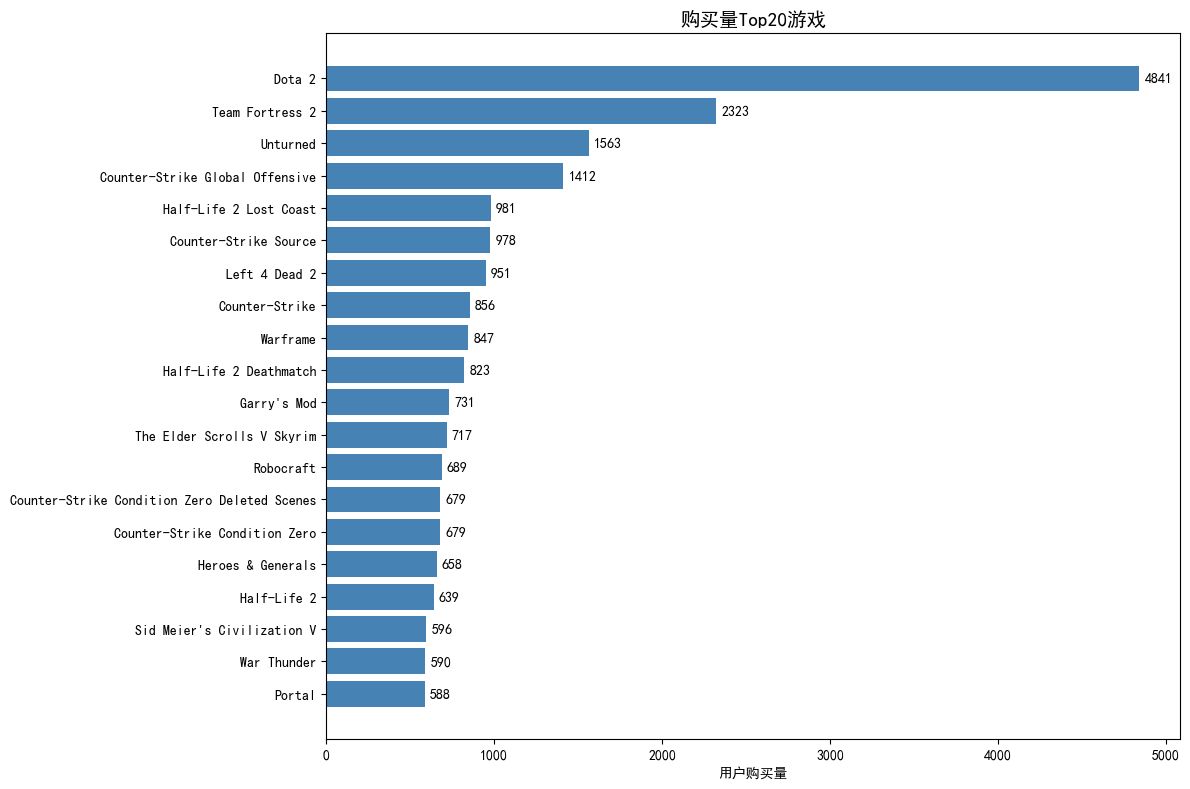

In [9]:
## 模块一
df1 = pd.read_csv('results/game_popularity1.csv')
plt.figure(figsize=(12, 8))
plt.barh(df1['game_title'], df1['purchase_count'], color='steelblue')
plt.title('购买量Top20游戏', fontsize=14)
plt.xlabel('用户购买量')
plt.gca().invert_yaxis()  # 最高的在最上面

# 数值标签
for i, v in enumerate(df1['purchase_count']):
    plt.text(v + 30, i, str(v), va='center')

plt.tight_layout()
plt.savefig('charts/01_purchase_top20.png', dpi=150)
plt.show()

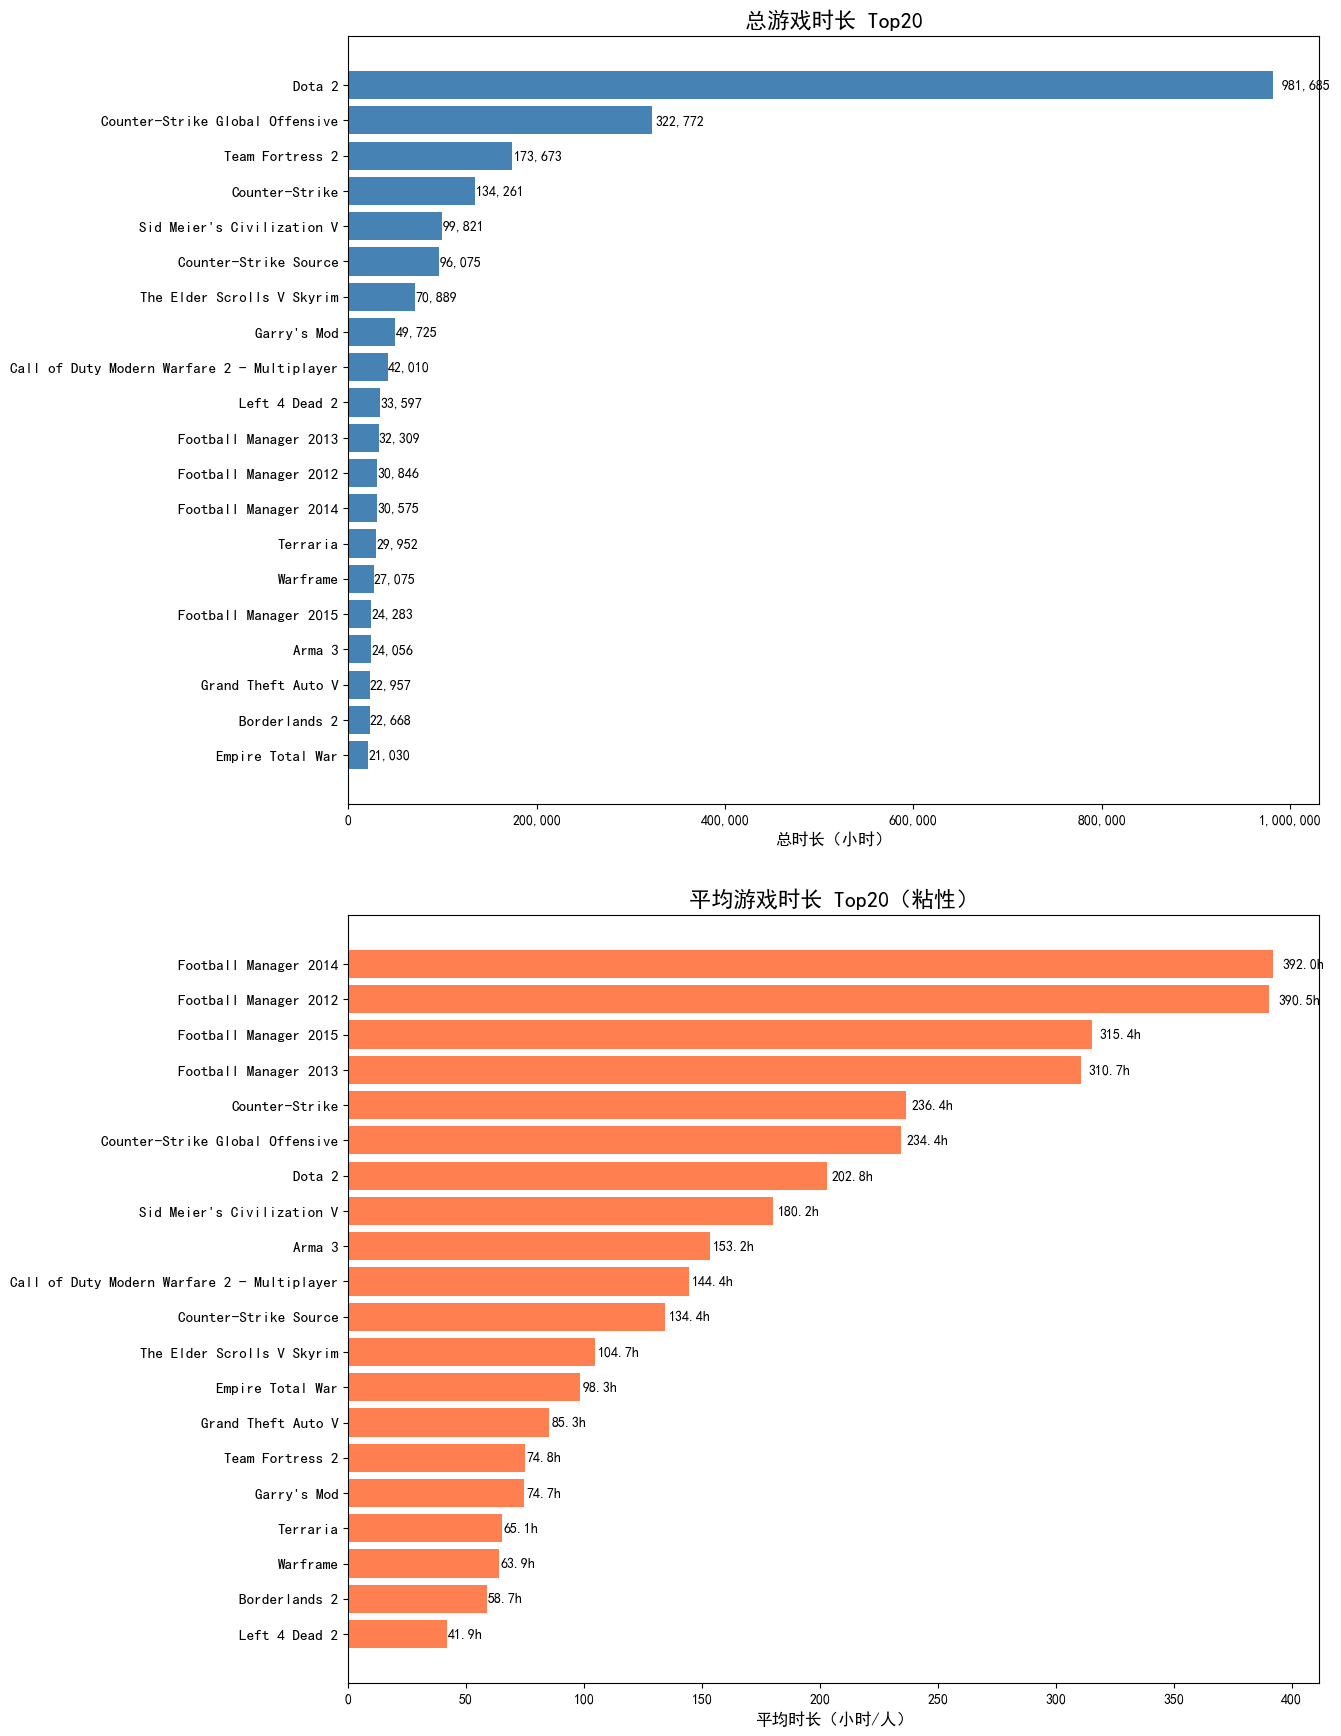

In [10]:
df2 = pd.read_csv('results/game_popularity2.csv')
fig, axes = plt.subplots(2, 1, figsize=(14, 18))  # 改成2行1列

# 图1：总时长Top20
axes[0].barh(df2['game_title'], df2['total_playtime'], color='steelblue')
axes[0].set_title('总游戏时长 Top20', fontsize=16)
axes[0].set_xlabel('总时长（小时）', fontsize=12)
axes[0].invert_yaxis()
axes[0].tick_params(axis='y', labelsize=11)

# 关键：关掉科学计数法
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}')
)

for i, v in enumerate(df2['total_playtime']):
    axes[0].text(v * 1.01, i, f'{int(v):,}', va='center', fontsize=10)

# 图2：平均时长Top20
df2_avg = df2.sort_values('avg_playtime', ascending=True)
axes[1].barh(df2_avg['game_title'], df2_avg['avg_playtime'], color='coral')
axes[1].set_title('平均游戏时长 Top20（粘性）', fontsize=16)
axes[1].set_xlabel('平均时长（小时/人）', fontsize=12)
axes[1].tick_params(axis='y', labelsize=11)
for i, v in enumerate(df2_avg['avg_playtime']):
    axes[1].text(v * 1.01, i, f'{v}h', va='center', fontsize=10)
    
plt.tight_layout(pad=3.0)  # 两图之间留间距
plt.savefig('charts/01_playtime_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

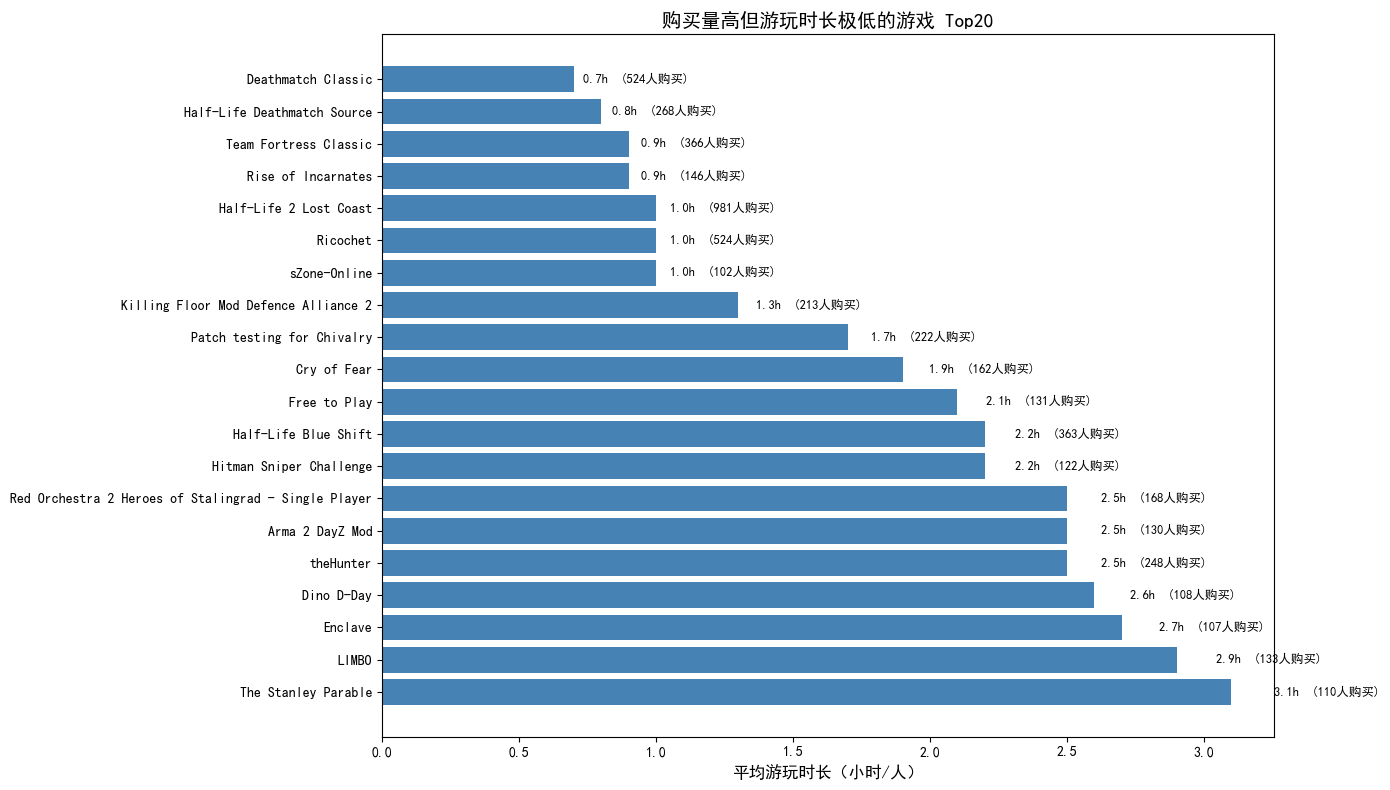

In [11]:
df3 = pd.read_csv('results/game_popularity3.csv')

fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(df3['game_title'], df3['avg_playtime'], color='steelblue')
ax.set_title('购买量高但游玩时长极低的游戏 Top20', fontsize=14)
ax.set_xlabel('平均游玩时长（小时/人）', fontsize=12)
ax.tick_params(axis='y', labelsize=10)
ax.invert_yaxis()

# 同时标注购买人数
for i, (v, p) in enumerate(zip(df3['avg_playtime'], df3['purchase_count'])):
    ax.text(v * 1.05, i, f'{v}h  ({p}人购买)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('charts/01_low_engagement.png', dpi=150, bbox_inches='tight')
plt.show()

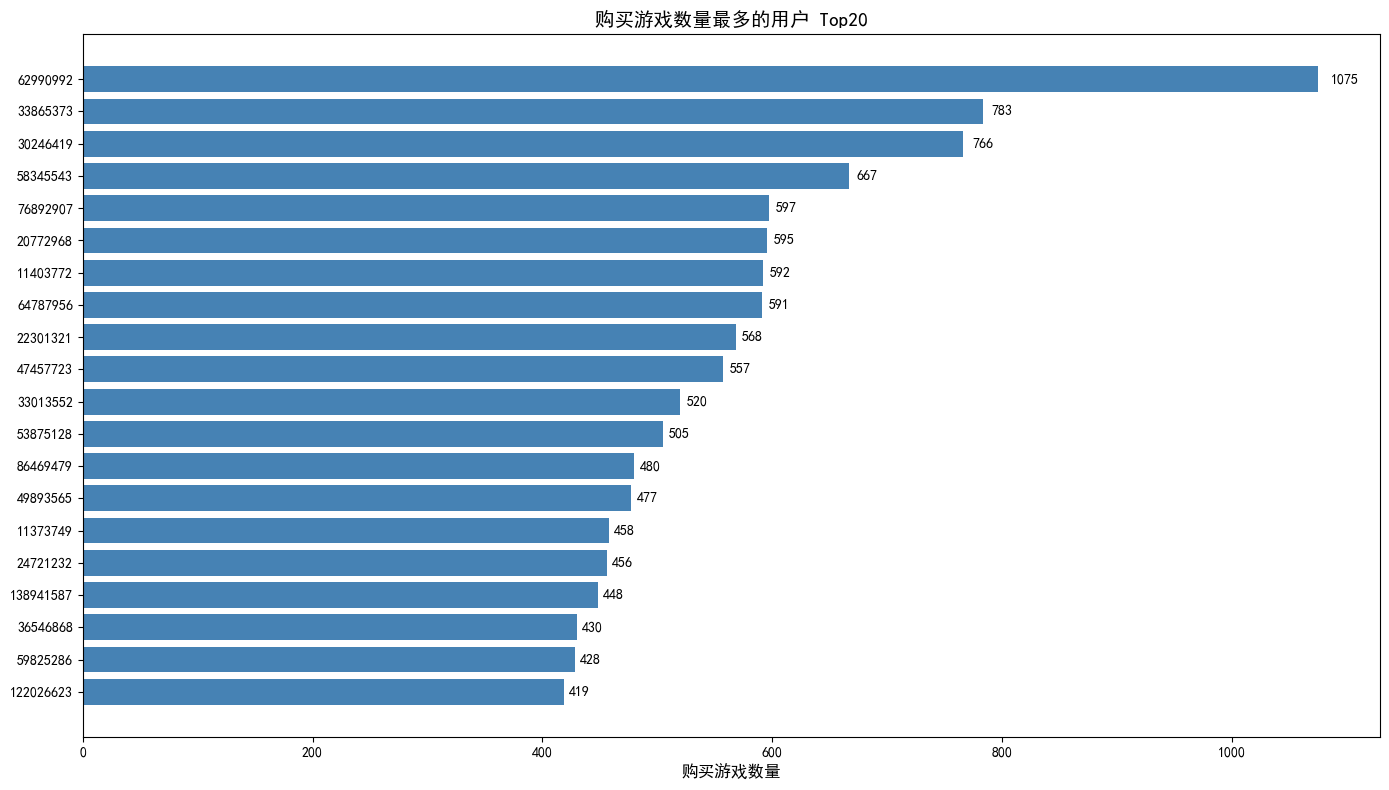

In [12]:
#模块2
df4 = pd.read_csv('results/user_behavior1.csv')

# 只取Top20展示
df4_top20 = df4.head(20)

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(df4_top20['user_id'].astype(str), 
        df4_top20['games_purchased'], color='steelblue')
ax.set_title('购买游戏数量最多的用户 Top20', fontsize=14)
ax.set_xlabel('购买游戏数量', fontsize=12)
ax.tick_params(axis='y', labelsize=10)
ax.invert_yaxis()

for i, v in enumerate(df4_top20['games_purchased']):
    ax.text(v * 1.01, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('charts/02_top_buyers.png', dpi=150, bbox_inches='tight')
plt.show()

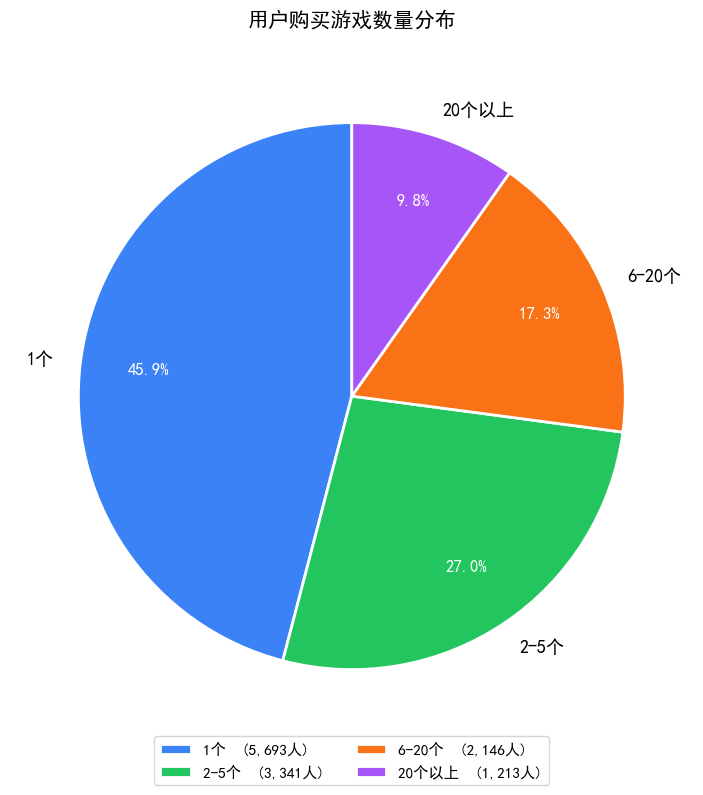

In [13]:
df5 = pd.read_csv('results/user_behavior2.csv')

# 排序让饼图从大到小展示
df5 = df5.sort_values('user_count', ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    df5['user_count'],
    labels=df5['purchase_range'],
    autopct='%1.1f%%',
    colors=['#3b82f6', '#22c55e', '#f97316', '#a855f7'],
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

# 字体大小
for text in texts:
    text.set_fontsize(13)
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_color('white')

ax.set_title('用户购买游戏数量分布', fontsize=15, pad=20)

# 加图例显示具体人数
legend_labels = [f'{r}  ({c:,}人)' for r, c in 
                 zip(df5['purchase_range'], df5['user_count'])]
ax.legend(wedges, legend_labels, loc='lower center',
          bbox_to_anchor=(0.5, -0.08), fontsize=11, ncol=2)

plt.tight_layout()
plt.savefig('charts/02_purchase_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

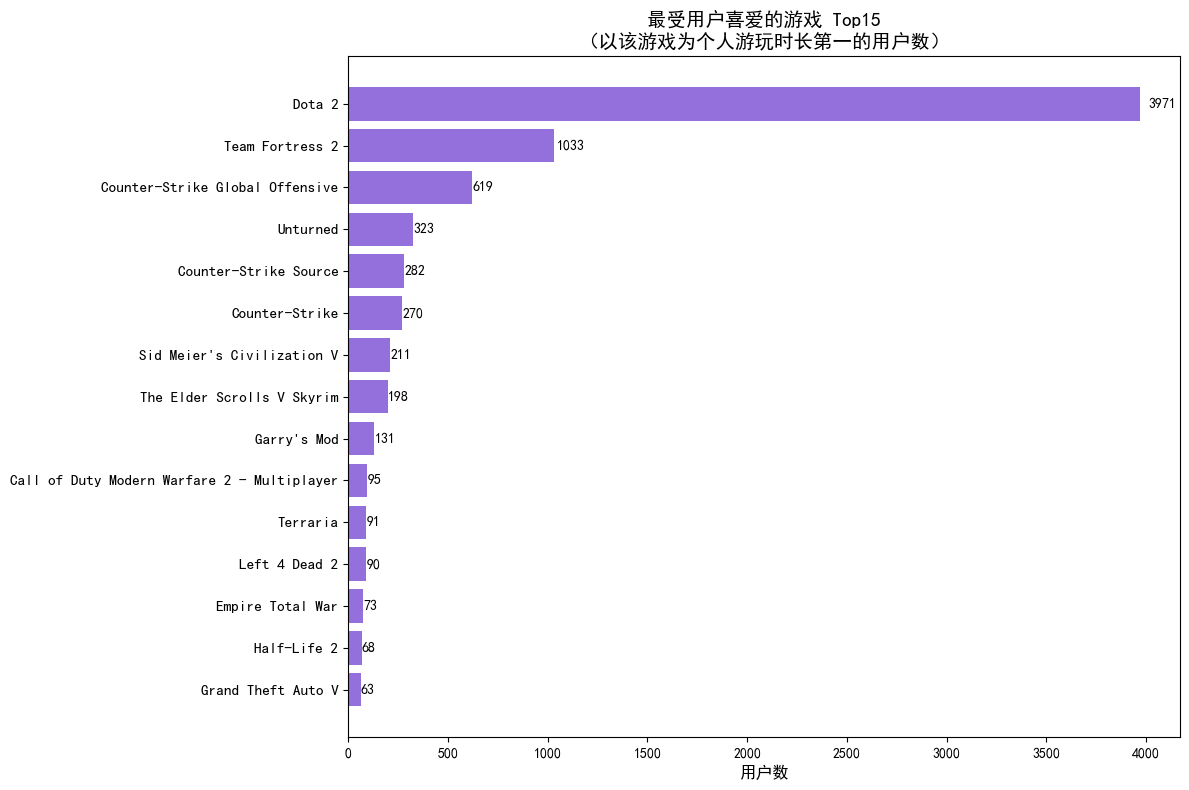

In [18]:
df6 = pd.read_csv('results/user_behavior3.csv')

# 统计各游戏作为「最爱游戏」的用户数
top_fav = df6['game_title'].value_counts().head(15).reset_index()
top_fav.columns = ['game_title', 'user_count']

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top_fav['game_title'], top_fav['user_count'], color='mediumpurple')
ax.set_title('最受用户喜爱的游戏 Top15\n（以该游戏为个人游玩时长第一的用户数）', fontsize=14)
ax.set_xlabel('用户数', fontsize=12)
ax.tick_params(axis='y', labelsize=11)
ax.invert_yaxis()

for i, v in enumerate(top_fav['user_count']):
    ax.text(v * 1.01, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('charts/02_favorite_games.png', dpi=150, bbox_inches='tight')
plt.show()

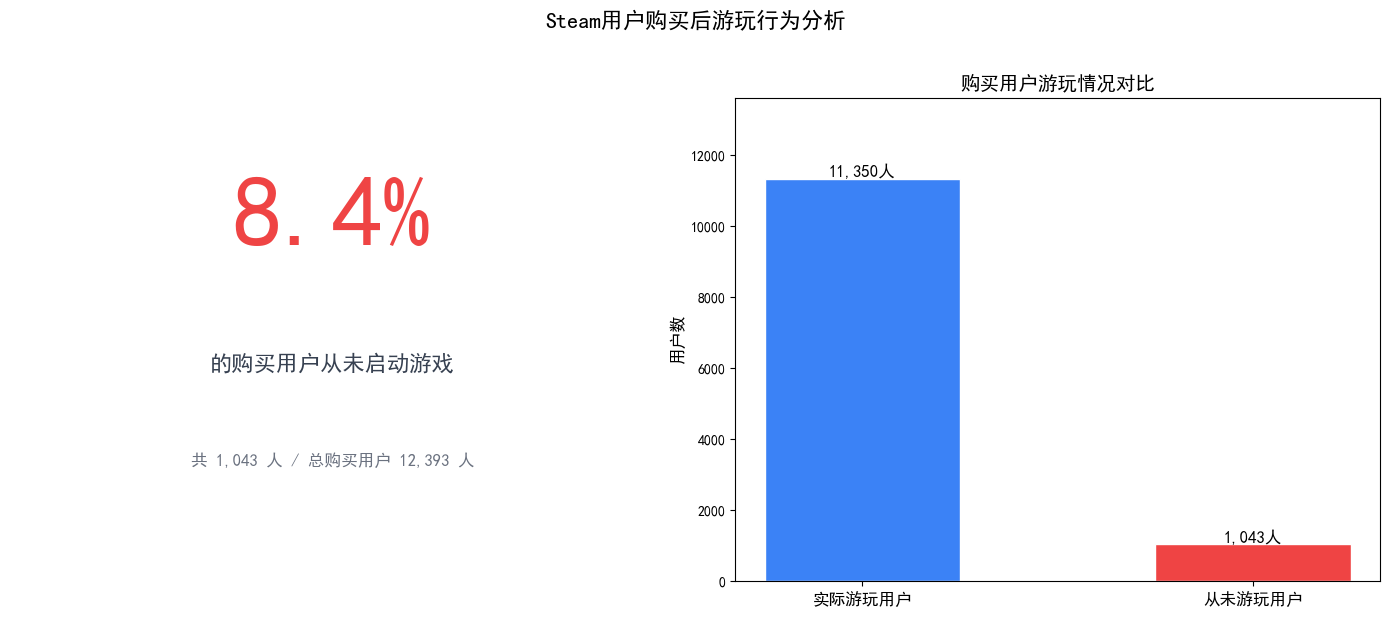

In [15]:
df7 = pd.read_csv('results/never_played_analysis1.csv')

# 取出数值
total = int(df7['total_buyers'][0])
played = int(df7['actual_players'][0])
never = int(df7['never_played'][0])
pct = float(df7['never_played_pct'][0])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左图：大数字展示
axes[0].axis('off')
axes[0].text(0.5, 0.75, f'{pct}%', ha='center', va='center',
             fontsize=72, fontweight='bold', color='#ef4444',
             transform=axes[0].transAxes)
axes[0].text(0.5, 0.45, '的购买用户从未启动游戏', ha='center', va='center',
             fontsize=16, color='#374151',
             transform=axes[0].transAxes)
axes[0].text(0.5, 0.25, f'共 {never:,} 人 / 总购买用户 {total:,} 人',
             ha='center', va='center', fontsize=12, color='#6b7280',
             transform=axes[0].transAxes)

# 右图：对比条形图
categories = ['实际游玩用户', '从未游玩用户']
values = [played, never]
colors = ['#3b82f6', '#ef4444']

bars = axes[1].bar(categories, values, color=colors, width=0.5, edgecolor='white')
axes[1].set_title('购买用户游玩情况对比', fontsize=14)
axes[1].set_ylabel('用户数', fontsize=12)

for bar, v in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 50,
                 f'{v:,}人', ha='center', fontsize=12, fontweight='bold')

axes[1].tick_params(axis='x', labelsize=12)
axes[1].set_ylim(0, total * 1.1)

plt.suptitle('Steam用户购买后游玩行为分析', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/04_never_played.png', dpi=150, bbox_inches='tight')
plt.show()
   


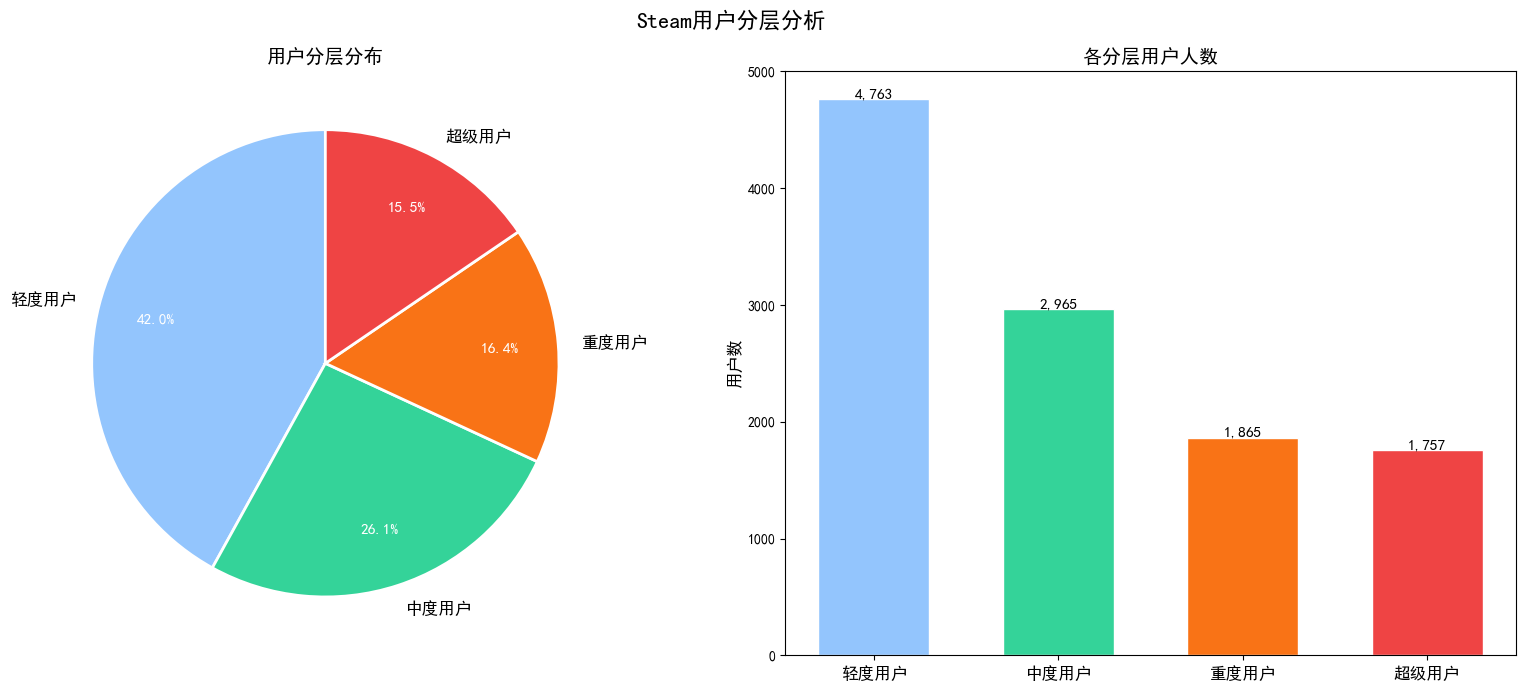

In [16]:
df_seg = pd.read_csv('results/user_tiering1.csv')

# 先汇总：统计每个分层的用户数量
seg_counts = df_seg['user_segment'].value_counts().reset_index()
seg_counts.columns = ['user_segment', 'user_count']

# 自定义排序（从轻到重）
order = ['轻度用户', '中度用户', '重度用户', '超级用户']
seg_counts['user_segment'] = pd.Categorical(
    seg_counts['user_segment'], categories=order, ordered=True
)
seg_counts = seg_counts.sort_values('user_segment')

# 画饼图
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 左图：饼图
colors = ['#93c5fd', '#34d399', '#f97316', '#ef4444']
wedges, texts, autotexts = axes[0].pie(
    seg_counts['user_count'],
    labels=seg_counts['user_segment'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for text in texts:
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_color('white')
axes[0].set_title('用户分层分布', fontsize=14)

# 右图：条形图（更直观看人数）
bars = axes[1].bar(seg_counts['user_segment'], 
                   seg_counts['user_count'],
                   color=colors, edgecolor='white', width=0.6)
axes[1].set_title('各分层用户人数', fontsize=14)
axes[1].set_ylabel('用户数', fontsize=12)
axes[1].tick_params(axis='x', labelsize=12)

for bar, v in zip(bars, seg_counts['user_count']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 5,
                 f'{v:,}', ha='center', fontsize=11)

plt.suptitle('Steam用户分层分析', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/03_user_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

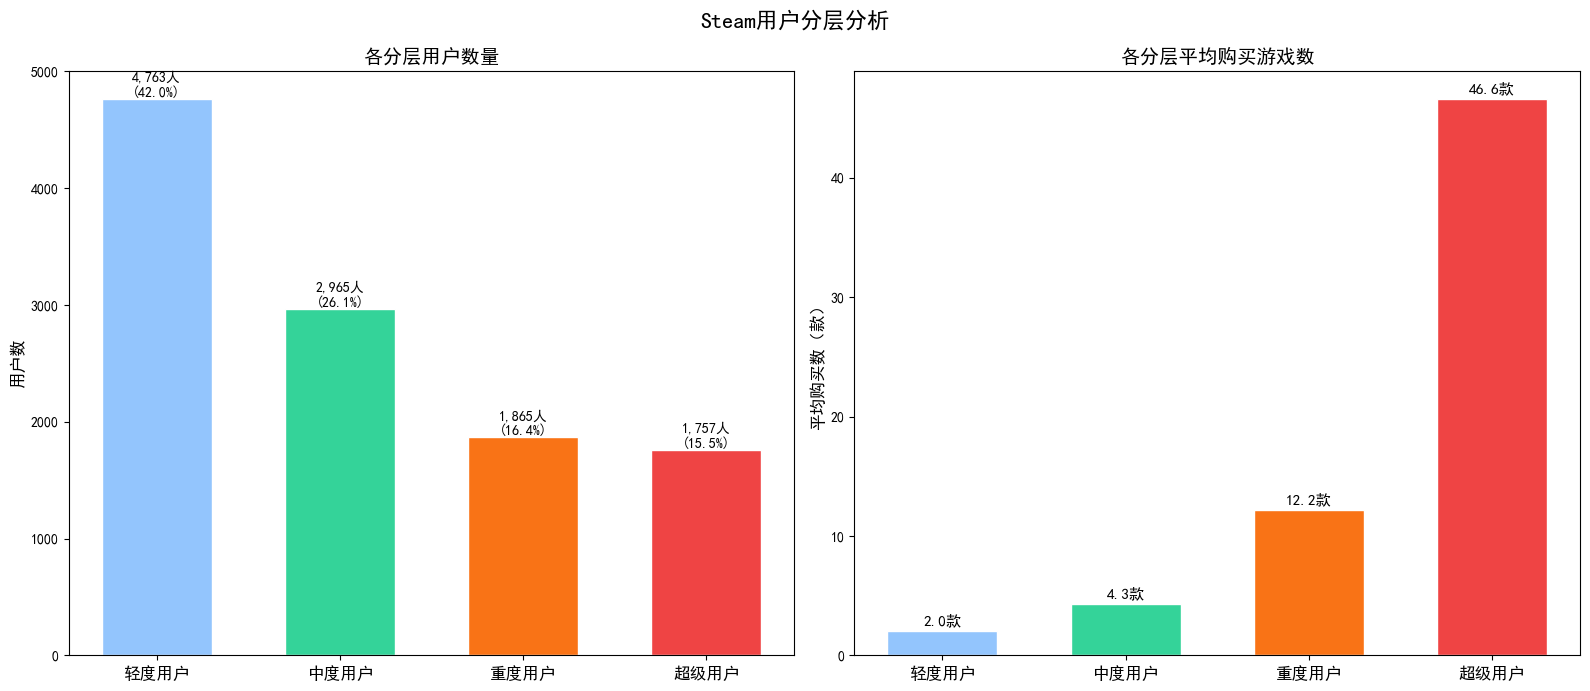

In [17]:
df_seg2 = pd.read_csv('results/user_tiering2.csv')

# 排序
order = ['轻度用户', '中度用户', '重度用户', '超级用户']
df_seg2['user_segment'] = pd.Categorical(
    df_seg2['user_segment'], categories=order, ordered=True
)
df_seg2 = df_seg2.sort_values('user_segment')

colors = ['#93c5fd', '#34d399', '#f97316', '#ef4444']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 左图：用户数量条形图（带百分比标注）
bars = axes[0].bar(df_seg2['user_segment'],
                   df_seg2['user_count'],
                   color=colors, edgecolor='white', width=0.6)
axes[0].set_title('各分层用户数量', fontsize=14)
axes[0].set_ylabel('用户数', fontsize=12)
axes[0].tick_params(axis='x', labelsize=12)

for bar, v, pct in zip(bars, df_seg2['user_count'], df_seg2['pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 20,
                 f'{v:,}人\n({pct}%)', ha='center', fontsize=10)

# 右图：各层平均购买游戏数
bars2 = axes[1].bar(df_seg2['user_segment'],
                    df_seg2['avg_games_purchased'],
                    color=colors, edgecolor='white', width=0.6)
axes[1].set_title('各分层平均购买游戏数', fontsize=14)
axes[1].set_ylabel('平均购买数（款）', fontsize=12)
axes[1].tick_params(axis='x', labelsize=12)

for bar, v in zip(bars2, df_seg2['avg_games_purchased']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.5,
                 f'{v}款', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Steam用户分层分析', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/03_user_segmentation2.png', dpi=150, bbox_inches='tight')
plt.show()